In [4]:
import pandas as pd

df = pd.read_csv("bitcoin.csv")

print(df.head())
print(df.info())

    Timestamp  Open  High   Low  Close  Volume
0  1325412060  4.58  4.58  4.58   4.58     0.0
1  1325412120  4.58  4.58  4.58   4.58     0.0
2  1325412180  4.58  4.58  4.58   4.58     0.0
3  1325412240  4.58  4.58  4.58   4.58     0.0
4  1325412300  4.58  4.58  4.58   4.58     0.0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 6 columns):
 #   Column     Non-Null Count    Dtype  
---  ------     --------------    -----  
 0   Timestamp  1048575 non-null  int64  
 1   Open       1048575 non-null  float64
 2   High       1048575 non-null  float64
 3   Low        1048575 non-null  float64
 4   Close      1048575 non-null  float64
 5   Volume     1048575 non-null  float64
dtypes: float64(5), int64(1)
memory usage: 48.0 MB
None


In [3]:
# Convert timestamp
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

# Sort data
df = df.sort_values('Timestamp')

# Check missing values
print(df.isnull().sum())

Timestamp    0
Open         0
High         0
Low          0
Close        0
Volume       0
dtype: int64


In [4]:
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1

print(IQR)

Timestamp    0 days 00:00:00.031457220
Open                            103.33
High                            103.42
Low                             103.21
Close                           103.31
Volume                        0.900332
dtype: object


In [5]:
outliers = df[(df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR))]
print(outliers)

        Timestamp    Open    High     Low   Close  Volume
0             NaT     NaN     NaN     NaN     NaN     NaN
1             NaT     NaN     NaN     NaN     NaN     NaN
2             NaT     NaN     NaN     NaN     NaN     NaN
3             NaT     NaN     NaN     NaN     NaN     NaN
4             NaT     NaN     NaN     NaN     NaN     NaN
...           ...     ...     ...     ...     ...     ...
1048570       NaT  711.49  711.49  711.49  711.49     NaN
1048571       NaT  711.49  711.49  711.49  711.49     NaN
1048572       NaT  711.45  711.45  711.45  711.45     NaN
1048573       NaT  711.45  711.45  711.45  711.45     NaN
1048574       NaT  711.45  711.45  711.45  711.45     NaN

[1048575 rows x 6 columns]


In [6]:
from scipy.stats import zscore

z_scores = df.apply(zscore)
print(z_scores)

         Timestamp      Open      High       Low     Close    Volume
0        -1.732049 -0.479010 -0.478786 -0.479245 -0.478999 -0.186370
1        -1.732046 -0.479010 -0.478786 -0.479245 -0.478999 -0.186370
2        -1.732043 -0.479010 -0.478786 -0.479245 -0.478999 -0.186370
3        -1.732039 -0.479010 -0.478786 -0.479245 -0.478999 -0.186370
4        -1.732036 -0.479010 -0.478786 -0.479245 -0.478999 -0.186370
...            ...       ...       ...       ...       ...       ...
1048570   1.732036  3.245833  3.239664  3.252703  3.245976 -0.186370
1048571   1.732039  3.245833  3.239664  3.252703  3.245976 -0.186370
1048572   1.732043  3.245622  3.239454  3.252492  3.245765 -0.138395
1048573   1.732046  3.245622  3.239454  3.252492  3.245765 -0.182689
1048574   1.732049  3.245622  3.239454  3.252492  3.245765 -0.160451

[1048575 rows x 6 columns]


In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

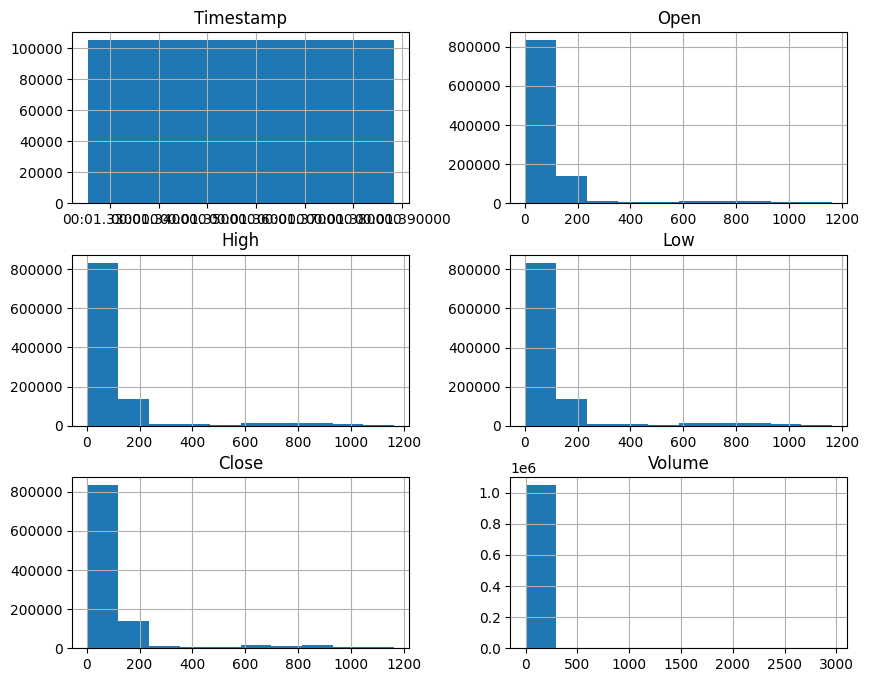

In [8]:
df.hist(figsize=(10,8))
plt.show()

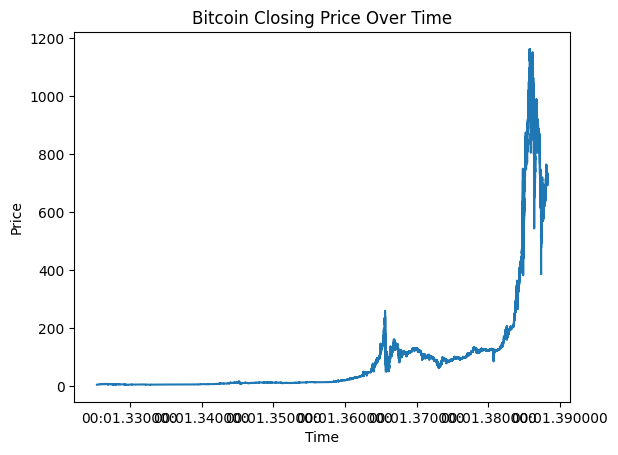

In [9]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(df['Timestamp'], df['Close'])
plt.title("Bitcoin Closing Price Over Time")
plt.xlabel("Time")
plt.ylabel("Price")
plt.show()

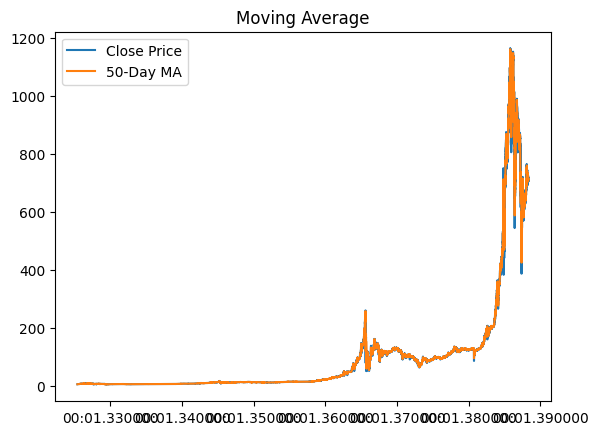

In [10]:
df['MA50'] = df['Close'].rolling(window=50).mean()

plt.figure()
plt.plot(df['Timestamp'], df['Close'], label='Close Price')
plt.plot(df['Timestamp'], df['MA50'], label='50-Day MA')
plt.legend()
plt.title("Moving Average")
plt.show()

In [11]:
df['target'] = df['Close'].shift(-1)

df = df.dropna()

X = df[['Open', 'High', 'Low', 'Close', 'Volume']]
y = df['target']

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

In [13]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [14]:
predictions = model.predict(X_test)

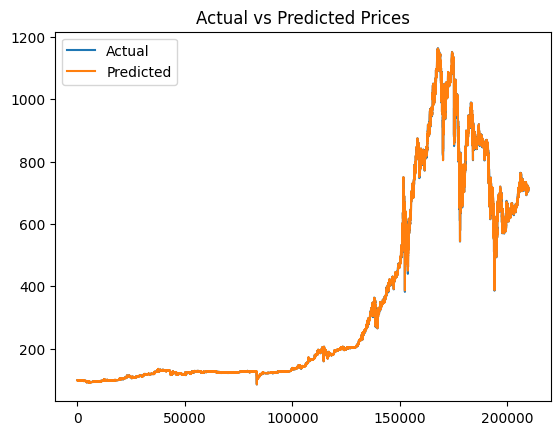

In [15]:
plt.figure()
plt.plot(y_test.values, label="Actual")
plt.plot(predictions, label="Predicted")
plt.legend()
plt.title("Actual vs Predicted Prices")
plt.show()

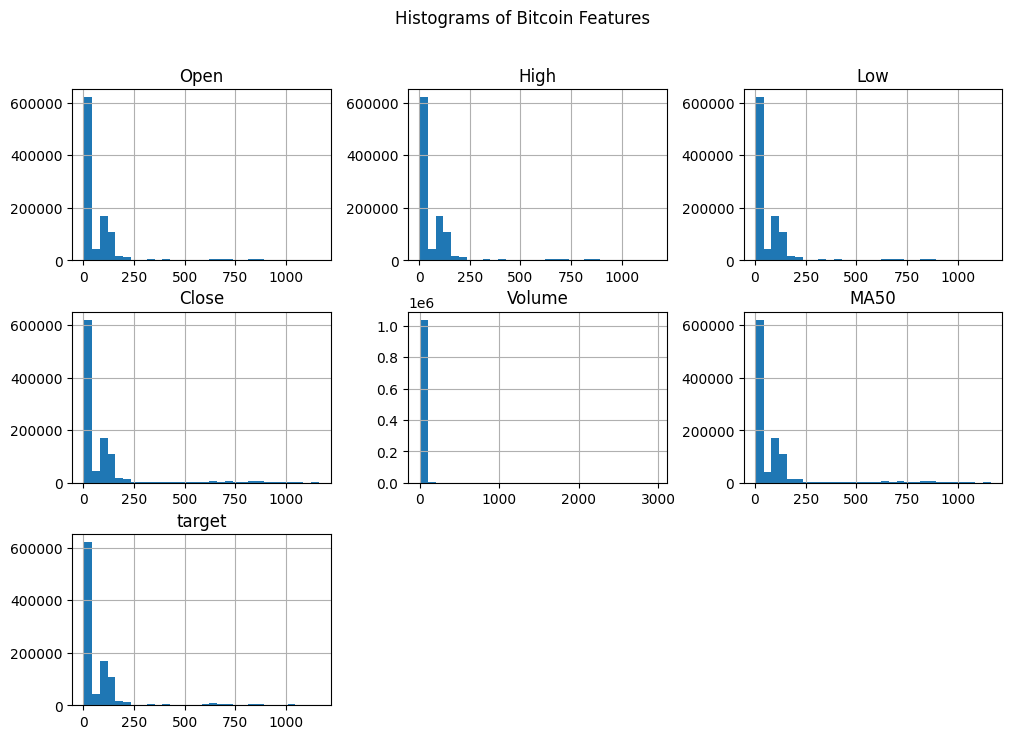

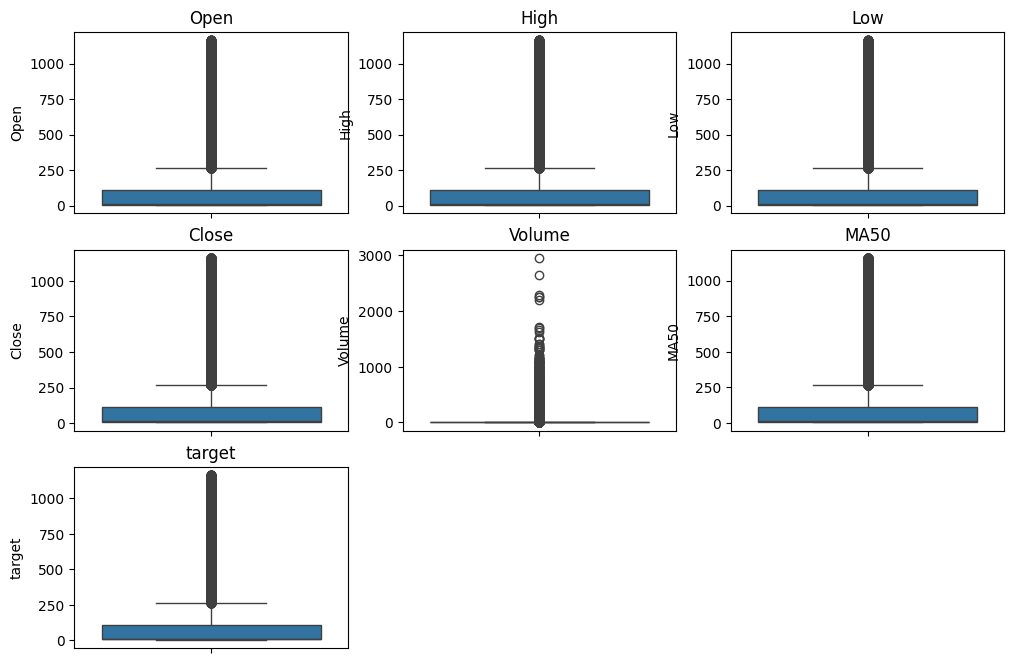

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select numeric columns
numeric = df.select_dtypes(include=['float64', 'int64'])

# Histograms
numeric.hist(bins=30, figsize=(12,8))
plt.suptitle("Histograms of Bitcoin Features")
plt.show()

# Boxplots
plt.figure(figsize=(12,8))
for i, col in enumerate(numeric.columns):
    plt.subplot(3,3,i+1)
    sns.boxplot(y=numeric[col])
    plt.title(col)
plt.show()

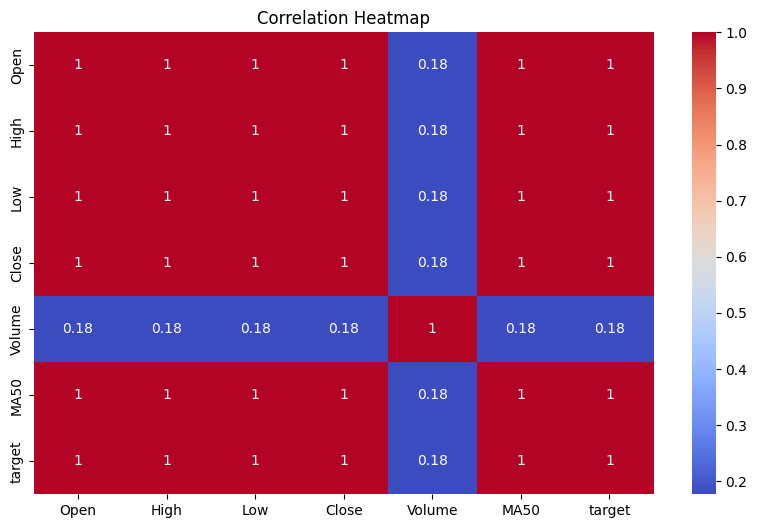

In [ ]:
corr = numeric.corr()

plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

sns.pairplot(numeric)
plt.show()

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

X = df[['Open','High','Low','Volume']]   # features
y = df['Close']                          # target

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("MSE:", mean_squared_error(y_test, y_pred))

MSE: 0.2879640347037654


In [6]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor()
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("DT MSE:", mean_squared_error(y_test, y_pred_dt))

DT MSE: 0.5537825688434309


In [8]:
from sklearn.neighbors import KNeighborsRegressor

knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)

print("KNN MSE:", mean_squared_error(y_test, y_pred_knn))

KNN MSE: 93129.71723995809


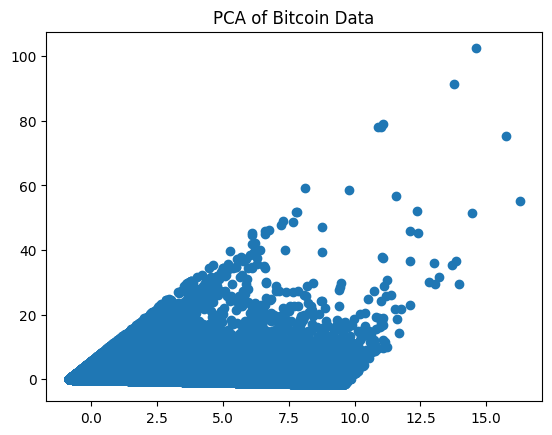

In [11]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.scatter(X_pca[:,0], X_pca[:,1])
plt.title("PCA of Bitcoin Data")
plt.show()

In [12]:
print("Linear Regression MSE:", mean_squared_error(y_test, y_pred))
print("Decision Tree MSE:", mean_squared_error(y_test, y_pred_dt))
print("KNN MSE:", mean_squared_error(y_test, y_pred_knn))

Linear Regression MSE: 193807.41705297286
Decision Tree MSE: 193805.776539385
KNN MSE: 93129.71723995809


In [13]:
from sklearn.metrics import r2_score
import numpy as np

print("----- Linear Regression -----")
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2:", r2_score(y_test, y_pred))

print("\n----- Decision Tree -----")
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_dt)))
print("R2:", r2_score(y_test, y_pred_dt))

print("\n----- KNN -----")
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_knn)))
print("R2:", r2_score(y_test, y_pred_knn))

----- Linear Regression -----
RMSE: 440.23563809961234
R2: -1.0015427438145972

----- Decision Tree -----
RMSE: 440.23377487351536
R2: -1.0015258014389241

----- KNN -----
RMSE: 305.17161932256755
R2: 0.03820445775718562


In [14]:
import pickle

pickle.dump(model, open("bitcoin_model.pkl", "wb"))